# Detecção de Fraude em Cartão de Crédito

## 5.1 - Identificação e Descrição do Problema

### Título
Detecção de Fraude em Cartão de Crédito.

### Integrantes
- Osanyo Victor Bevitori Nascimento - @osanyovictor
- Raíssa Cavalcante de Albuquerque Bitencurte - @raissabac
- Filipe Ciríaco Marcelino do Nascimento - @VilefilipeDCOMP

### Fonte dos Dados
Os dados utilizados neste projeto são provenientes do Kaggle, especificamente do dataset "Credit Card Fraud Detection" (mlg-ulb/creditcardfraud). Este dataset contém transações realizadas por cartões de crédito em setembro de 2013 por portadores europeus, caracterizado por ser um conjunto de dados altamente desbalanceado.

### Objetivo
Desenvolver um modelo de Inteligência Artificial capaz de detectar se uma transação de cartão de crédito é legítima ou fraudulenta.

### Atributo-alvo
`Class`: variável binária que indica a natureza da transação:
- 0: Transação legítima (Normal)
- 1: Transação fraudulenta (Fraude)

### Atributos Preditivos
- `Time`: segundos decorridos entre cada transação e a primeira transação da base;
- `V1`–`V28`: componentes resultantes de uma transformação PCA, anonimizados por questões de sigilo dos dados originais;
- `Amount`: valor monetário da transação.

### Tipo da Tarefa
Classificação Binária, pois o atributo-alvo representa duas categorias mutuamente exclusivas (legítima ou fraude). Por esse motivo foram adotados modelos e métricas de classificação.

In [1]:
pip install kagglehub pandas scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path + '/creditcard.csv')

## 5.2 - Compreensão dos dados

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Quantidade de registros (transações com cartão): " + str(df.shape[0]))
print("Quantidade de atributos: " + str(df.shape[1]))
print("Variáveis: " + str(list(df.keys())))

Quantidade de registros (transações com cartão): 284807
Quantidade de atributos: 31
Variáveis: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
print("Quantidade de valores ausentes por variavel:")
df.isnull().sum()

Quantidade de valores ausentes por variavel:


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
print("Linhas duplicadas: " + str(df.duplicated().sum()))
print("Dataset com as linhas duplicadas: " + str(df.shape[0]))
print("Dataset sem as linhas duplicadas: " + str((df.drop_duplicates()).shape[0]))
df[df.duplicated()]

Linhas duplicadas: 1081
Dataset com as linhas duplicadas: 284807
Dataset sem as linhas duplicadas: 283726


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


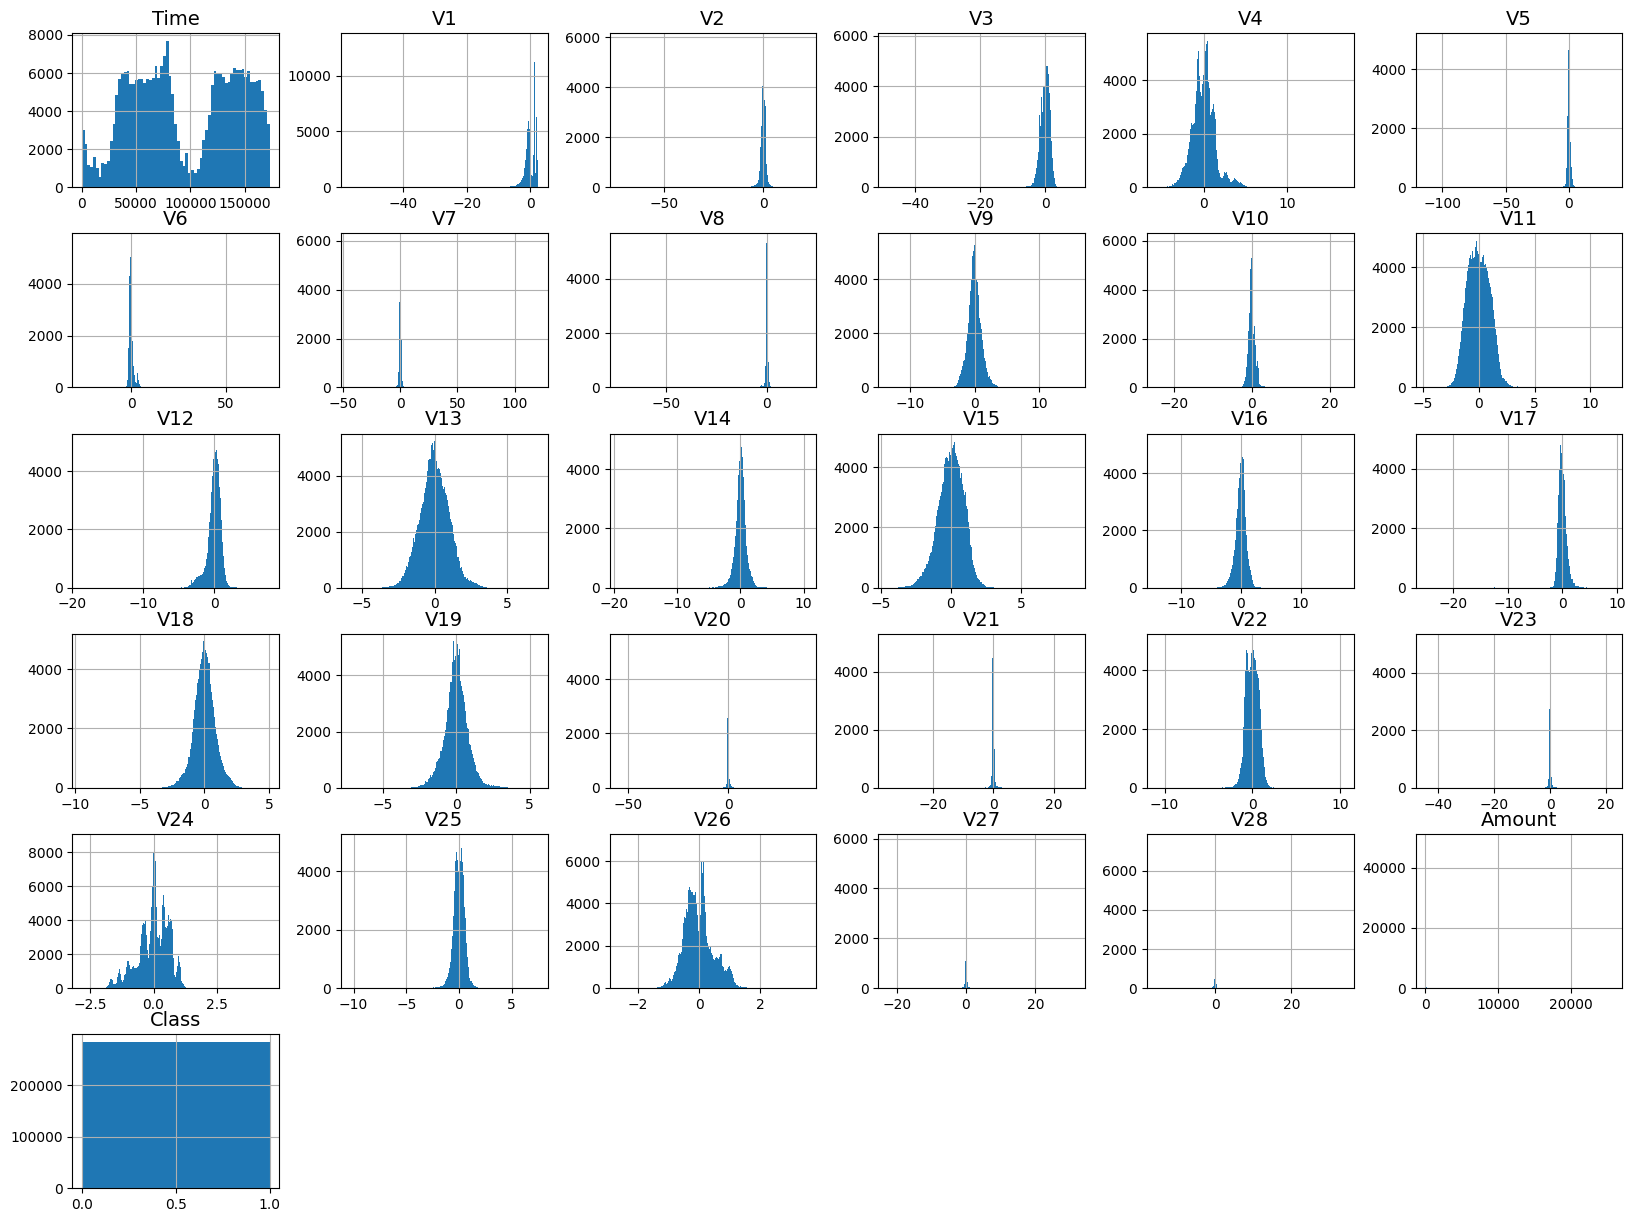

In [7]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# 'fd' para determinar dinamicamente as bins
df.hist(bins='fd', figsize=(20, 15))
plt.show()

In [8]:
# Distribuicao do atributo-alvo
contagem = df['Class'].value_counts()
prop = df['Class'].value_counts(normalize=True) * 100
print(contagem)
print()
print("Percentual (%):")
print(prop.round(3))

Class
0    284315
1       492
Name: count, dtype: int64

Percentual (%):
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


**Interpretação**: O dataset é extremamente desbalaceado, tendo somente 492 exemplos de fraudes comparado a 284.315 exemplos de transações reais (0.173%).

In [9]:
#verificação da inconsistencia no valor na transação
print(df[['Time', 'Amount']].min())

Time      0.0
Amount    0.0
dtype: float64


In [10]:
#compara valores máximos e mínimos de colunas diferentes
print(df[['Amount', 'V1', 'V2']].agg(['min', 'max']))

       Amount        V1         V2
min      0.00 -56.40751 -72.715728
max  25691.16   2.45493  22.057729


## 5.3 - Análise exploratória

In [11]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["V1"].sort_values(ascending=False)

V1        1.000000e+00
Time      1.173963e-01
V28       2.083082e-15
V23       6.168652e-16
V20       4.654551e-16
V2        4.135835e-16
V15       3.547782e-16
V11       2.125498e-16
V12       2.053457e-16
V19       1.502024e-16
V27       1.198124e-16
V10       7.388135e-17
V16       7.212815e-17
V18       3.230206e-17
V5        1.812612e-17
V26      -1.581290e-17
V13      -2.425603e-17
V24      -4.425156e-17
V9       -1.513678e-16
V8       -2.433822e-16
V21      -2.457409e-16
V17      -3.879840e-16
V22      -4.290944e-16
V14      -5.020280e-16
V6       -6.506567e-16
V4       -9.215150e-16
V25      -9.605737e-16
V7       -1.005191e-15
V3       -1.227819e-15
Class    -1.013473e-01
Amount   -2.277087e-01
Name: V1, dtype: float64

In [12]:
## Correlações entre atributos

df.corr()["Class"].abs().sort_values(ascending=False)

Class     1.000000
V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64

In [13]:
#faz a analise em cima do valor financeiro de cada transação do cartão de crédito
#aqui ele pega só os valores de transações normais e fraude, e aplica os calculos da tabela
tabela_dispersao = df.groupby('Class')['Amount'].describe()
tabela_dispersao = tabela_dispersao.rename(columns={
    'count': 'Quantidade',
    'mean': 'Média',
    'std': 'Desvio Padrão',
    'min': 'Mínimo',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Máximo'
})
tabela_dispersao.index = ['Normal (0)', 'Fraude (1)']

display(tabela_dispersao)

,Quantidade,Média,Desvio Padrão,Mínimo,1º Quartil (25%),Mediana (50%),3º Quartil (75%),Máximo
Normal (0),284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
Fraude (1),492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## 5.4 - Pré-Processamento


### **Valores ausentes**

Problema: A verificação **feita** com df.isnull().sum() retornou zero para todas as variáveis.

Tratamento: Nenhum.

Justificativa: Como não há dados faltantes no dataset, não foi necessária a aplicação de técnicas de preenchimento (imputação) ou remoção de linhas.

### **Variáveis Categóricas**

**Problema**: O dataset contém exclusivamente valores numéricos (float64 e int64), sem colunas de texto.

**Tratamento**: Nenhum.

**Justificativa**: Como não há variáveis categóricas, técnicas de conversão (como One-Hot Encoding) não foram aplicadas, pois os dados já estão no formato matemático adequado para os modelos.

### **Remoção de duplicações**

Problema: O comando duplicated() revelou a presença de 1.081 registros idênticos na base.

Tratamento: Utilização do método drop_duplicates() para remover as cópias.

Justificativa: A remoção é essencial para evitar que os modelos sofram overfitting (decorem exemplos repetidos) e para impedir o vazamento de cópias exatas entre os conjuntos de treino e teste.  

In [14]:
df = df.drop_duplicates()

### **Remoção de atributos irrelevantes**

**Problema:** Avaliação do poder preditivo das colunas Time e Amount.

**Tratamento:** Nenhuma coluna foi removida.

**Justificativa:** Embora Time represente apenas os segundos decorridos, decidimos mantê-la para avaliar seu impacto preditivo. A coluna Amount foi mantida por ser o valor da transação, algo crucial no contexto financeiro.

### **Correção de inconsistências**
**Problema:** Possíveis anomalias lógicas nos dados originais.

**Tratamento:** Nenhuma linha foi alterada.

**Justificativa:** Analisando os valores mínimos com o método .min(), não foram encontrados valores financeiros negativos em Amount ou tempos negativos em Time. Para os atributos anonimizados (V1 a V28), assumimos a consistência da transformação PCA original.

### **Tratamento de valores extremos (Outliers)**

Problema: A análise exploratória apresentou alta dispersão e presença de outliers na coluna Amount.

Tratamento: Os outliers não foram removidos.

Justificativa: No contexto de detecção de fraude bancária, os valores anômalos frequentemente representam a própria fraude. Removê-los causaria a perda da informação mais valiosa para a resolução do problema.

### **Tratamento de classes desbalanceadas**

Problema: O método value_counts(normalize=True) comprovou o desbalanceamento extremo: 99,8% dos dados são da classe 0 (Normal) e apenas 0,17% da classe 1 (Fraude).

Tratamento: Uso do parâmetro class_weight='balanced' diretamente nos classificadores.

Justificativa: Essa abordagem força o algoritmo a dar um peso matematicamente maior aos erros cometidos na previsão da classe minoritária, sem a necessidade de criar dados sintéticos.

### **Escalonamento**

Problema: A função .agg(['min', 'max']) evidenciou que a coluna Amount possui uma escala de grandeza na casa dos milhares, completamente diferente das variáveis V1 a V28 (unidades decimais).

Tratamento: Aplicação do StandardScaler apenas nas colunas Time e Amount.

Justificativa: O escalonamento nivela as escalas para não distorcer os pesos no modelo. Para evitar vazamento de informação, o escalonador aprendeu os limites (fit) exclusivamente no conjunto de treinamento.

## 5.5 - Separação dos dados

Separação treinamento e teste :

Os dados foram divididos em variáveis preditivas (X) e atributo-alvo (y), e separados em conjuntos de treino e teste.

Justificativa da Proporção :

Adotamos a divisão de 80% para treinamento e 20% para teste (test_size=0.2). Como o dataset possui um volume massivo de registros (mais de 284 mil), 20% garante um conjunto de teste com tamanho estatisticamente robusto (aprox. 56 mil transações) para a avaliação final, enquanto o modelo ainda tem amsi de 227 mil dados para aprender.

Estratificação :

Foi aplicada a estratificação (stratify=y) devido ao extremo desbalanceamento da classe alvo (0,17% de fraudes). Isso assegura que a exata proporção de fraudes seja preservada em ambos os conjuntos, evitando o risco estatístico de um conjunto de teste sem exemplos da classe minoritária.

Reserva do conjunto de teste :

Para evitar o vazamento de informações (data leakage), o conjunto de teste foi completamente isolado. O tratamento de valores em Amount (transformação logarítmica) foi aplicado de forma independente. O escalonamento (StandartScaler) "aprendeu" (fit) exclusivamente com os dados de treinamento, e o teste recebeu apenas a transformação (transform).

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

#separar quem é característica (X) de quem é o alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

X['Amount'] = np.log1p(X['Amount'])

#separação dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

# escalonamento
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Time', 'Amount']) # Aplica apenas nas colunas não padronizadas
    ],
    remainder='passthrough'
)

## 5.6 - Modelagem

Adiciona um limite global de uso das threads do processador.

 - -1 = Usa todos os núcleos disponíveis

In [22]:
num_threads = 10

Utilizamos como baseline o **DummyClassifier**, um modelo que faz previsões se baseando unicamente na estratégia passada como argumento. Nesse caso, adotamos a estratégia “most_frequent”, na qual o modelo sempre prevê a classe mais frequente no dataset.

Como o dataset é extremamente desbalanceado, sua acurácia apresenta um valor alto tanto na etapa de treino quanto na de teste, mascarando as reais métricas de desempenho do modelo. O resultado de acurácia obtido no conjunto de teste servirá como referência de comparação, permitindo perceber se o modelo está de fato aprendendo algum padrão relevante ou apenas "chutando" a classe mais frequente, assim como o DummyClassifier.

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy="most_frequent", random_state=123))
])

pipeline_completo.fit(X_train, y_train)

dummy_train_accuracy = pipeline_completo.score(X_train, y_train)
dummy_test_accuracy = pipeline_completo.score(X_test, y_test)
y_scores_test = pipeline_completo.predict_proba(X_test)[:, 1]
dummy_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("DummyClassifier")
print("Acurácia no dataset de treino: " + str(dummy_train_accuracy))
print("Acurácia no dataset de teste: " + str(dummy_test_accuracy))
print("Average precision no dataset de teste: " + str(dummy_test_avgprecision))


DummyClassifier
Acurácia no dataset de treino: 0.998334655035686
Acurácia no dataset de teste: 0.9983258731892997
Average precision no dataset de teste: 0.0016741268107003137


O segundo modelo é o **SGDClassifier**, um modelo que usa classificação linear com treino SGD. Nesse bloco, rodaremos apenas a sua versão padrão, com os parâmetros autodefinidos.

In [18]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(class_weight="balanced", random_state=123, n_jobs=num_threads))
])

pipeline_completo.fit(X_train, y_train)

sgd_train_accuracy = pipeline_completo.score(X_train, y_train)
sgd_test_accuracy = pipeline_completo.score(X_test, y_test)
y_scores_test = pipeline_completo.decision_function(X_test) ## Precisa ser no lugar do predict_proba, uma vez que o "hinge" não suporta a função.
sgd_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("SGDClassifier")
print("Acurácia no dataset de treino: " + str(sgd_train_accuracy))
print("Acurácia no dataset de teste: " + str(sgd_test_accuracy))
print("Average precision no dataset de teste: " + str(sgd_test_avgprecision))

SGDClassifier
Acurácia no dataset de treino: 0.9666931007137193
Acurácia no dataset de teste: 0.9674162055475276
Average precision no dataset de teste: 0.8057621308844991


O terceiro modelo é o **RandomForestClassifier**,  um modelo baseado em um conjunto de árvores de decisão. Cada árvore é treinada com uma amostra aleatória dos dados e das features, e a classificação final é definida pela votação majoritária entre todas as árvores. Nesse bloco, rodaremos apenas a sua versão padrão, com os parâmetros autodefinidos.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight="balanced", random_state=123, n_jobs=num_threads))
])

pipeline_completo.fit(X_train, y_train)

rf_train_accuracy = pipeline_completo.score(X_train, y_train)
rf_test_accuracy = pipeline_completo.score(X_test, y_test)
y_scores_test = pipeline_completo.predict_proba(X_test)[:, 1]
rf_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("RandomForestClassifier")
print("Acurácia no dataset de treino: " + str(rf_train_accuracy))
print("Acurácia no dataset de teste: " + str(rf_test_accuracy))
print("Average precision no dataset de teste: " + str(rf_test_avgprecision))

RandomForestClassifier
Acurácia no dataset de treino: 1.0
Acurácia no dataset de teste: 0.9995946850879357
Average precision no dataset de teste: 0.8637395404066346


Nessa seção, faremos uma busca exaustiva em grid por parâmetros que possam melhorar a performance do modelo final. 

Todos os GridSearchCV são configurados para fazer uma validação cruzada com 5 folds, permitindo que o resultado do modelo seja mais estável ao ser retreinado 5 vezes com divisões diferentes do dataset de treino (4 folds para treino e 1 fold para validação). Além disso, o GridSearchCV possui a configuração de estratificar por padrão, evitando que exista algum fold com poucos ou nenhuma fraude.

A métrica "average_precision" foi utilizada no lugar do padrão "accuracy", uma vez que a acurácia se mostra enganosa em datasets tão desbalanceados quanto este. Essa métrica considera a precisão e o recall em vários limiares (thresholds), em vez de se limitar a um único limiar fixo, o que permite comparar os modelos de forma mais geral, sem depender de uma escolha prévia de limiar.

Para o Dummy Classifier:
- "strategy": Altera a estrategia utilizada para gerar as previsões

In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.dummy import DummyClassifier

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy="most_frequent", random_state=123))
])

param_grid = {
    "model__strategy": ["most_frequent", "prior", "stratified", "uniform"],
}

model = DummyClassifier(random_state=123)
dummy_grid = GridSearchCV(pipeline_completo, param_grid, cv=5, scoring="average_precision", n_jobs=num_threads)
dummy_grid.fit(X_train, y_train)

print(f"Melhor average precision na validação cruzada: {dummy_grid.best_score_:.3f}")
print(f"Hiperparâmetros ótimos: {dummy_grid.best_params_}")

Melhor average precision na validação cruzada: 0.002
Hiperparâmetros ótimos: {'model__strategy': 'stratified'}


Para o SGDClassifier:

- "loss": Altera a função de perda (loss function) utilizada pelo modelo, sendo o padrão "hinge", que corresponde a um SVM linear.
- "penaly": Altera o regularizador do modelo, sendo o padrão "l2".
- "max_iter": É o limite máximo de iterações de treinamento. Foi utilizado um valor alto (5000) para assegurar que o otimizador tenha iterações suficientes para atingir seu melhor resultado sem ser interrompido.

O learning_rate foi utilizado como "adaptive" para evitar que o SGDClassifier fique travado rodando sem conseguir convergir a um resultado final adequado.

In [23]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import SGDClassifier

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(learning_rate="adaptive", max_iter=5000, class_weight="balanced", random_state=123, n_jobs=num_threads))
])

param_grid = {
    "model__loss": ["hinge", "log_loss", "modified_huber"],
    "model__penalty": ["l2", "l1"],
}

sgd_grid = GridSearchCV(pipeline_completo, param_grid, cv=5, scoring="average_precision", n_jobs=num_threads)
sgd_grid.fit(X_train, y_train)

print(f"Melhor average precision na validação cruzada: {sgd_grid.best_score_:.3f}")
print(f"Hiperparâmetros ótimos: {sgd_grid.best_params_}")

Melhor average precision na validação cruzada: 0.713
Hiperparâmetros ótimos: {'model__loss': 'log_loss', 'model__penalty': 'l2'}


Para o RandomForestClassifier:

- "n_estimators": Define o número de árvores de decisão que compõem a floresta, sendo o padrão "100".
- "max_depth": Define a profundidade máxima de cada árvore, sendo o padrão "None" (sem limite de profundidade).
- "max_features": Define o número máximo de features consideradas ao buscar a melhor divisão em cada nó, sendo o padrão "sqrt", que utiliza a raiz quadrada do número total de features.

In [24]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

pipeline_completo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight="balanced", random_state=123, n_jobs=num_threads))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(pipeline_completo, param_grid, cv=5, scoring="average_precision", n_jobs=num_threads)
rf_grid.fit(X_train, y_train)

print(f"Melhor average precision na validação cruzada: {rf_grid.best_score_:.3f}")
print(f"Hiperparâmetros ótimos: {rf_grid.best_params_}")

Melhor average precision na validação cruzada: 0.826
Hiperparâmetros ótimos: {'model__max_depth': None, 'model__max_features': 'log2', 'model__n_estimators': 150}


Agora retreinado o modelo com os parâmetros otimizados do GridSearch

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

## DummyClassifier

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy=dummy_grid.best_params_["model__strategy"], random_state=123))
])

dummy_pipeline.fit(X_train, y_train)

dummy_train_accuracy = dummy_pipeline.score(X_train, y_train)
dummy_test_accuracy = dummy_pipeline.score(X_test, y_test)
y_scores_test = dummy_pipeline.predict_proba(X_test)[:, 1]
dummy_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("DummyClassifier")
print("Acurácia no dataset de treino: " + str(dummy_train_accuracy))
print("Acurácia no dataset de teste: " + str(dummy_test_accuracy))
print("Average precision no dataset de teste: " + str(dummy_test_avgprecision))

## SGDClassifier

sgd_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(loss=sgd_grid.best_params_["model__loss"], penalty=sgd_grid.best_params_["model__penalty"], class_weight="balanced", random_state=123, n_jobs=num_threads))
])

sgd_pipeline.fit(X_train, y_train)

sgd_train_accuracy = sgd_pipeline.score(X_train, y_train)
sgd_test_accuracy = sgd_pipeline.score(X_test, y_test)
# y_scores_test = sgd_pipeline.predict_proba(X_test)[:, 1]
y_scores_test = sgd_pipeline.decision_function(X_test) ## Precisa ser no lugar do predict_proba, uma vez que o "hinge" não suporta a função.
sgd_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("\nSGDClassifier")
print("Acurácia no dataset de treino: " + str(sgd_train_accuracy))
print("Acurácia no dataset de teste: " + str(sgd_test_accuracy))
print("Average precision no dataset de teste: " + str(sgd_test_avgprecision))

## RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=rf_grid.best_params_["model__n_estimators"], max_depth=rf_grid.best_params_["model__max_depth"], max_features=rf_grid.best_params_["model__max_features"], random_state=123, n_jobs=num_threads))
])
rf_pipeline.fit(X_train, y_train)

rf_train_accuracy = rf_pipeline.score(X_train, y_train)
rf_test_accuracy = rf_pipeline.score(X_test, y_test)
y_scores_test = rf_pipeline.predict_proba(X_test)[:, 1]
rf_test_avgprecision = average_precision_score(y_test, y_scores_test)

print("\nRandomForestClassifier")
print("Acurácia no dataset de treino: " + str(rf_train_accuracy))
print("Acurácia no dataset de teste: " + str(rf_test_accuracy))
print("Average precision no dataset de teste: " + str(rf_test_avgprecision))

DummyClassifier
Acurácia no dataset de treino: 0.9966208476517755
Acurácia no dataset de teste: 0.9965107672787509
Average precision no dataset de teste: 0.0016741268107003137

SGDClassifier
Acurácia no dataset de treino: 0.9613137721385144
Acurácia no dataset de teste: 0.9620237549783245
Average precision no dataset de teste: 0.7996227034885727

RandomForestClassifier
Acurácia no dataset de treino: 1.0
Acurácia no dataset de teste: 0.9996123074754167
Average precision no dataset de teste: 0.8686318143782994


Escolhemos o RandomForestClassifier como modelo final, pois este obteve o melhor average precision entre todos os modelos no dataset de teste (aproximadamente 0,87), superando tanto o SGDClassifier (aprox. 0,80) quanto o DummyClassifier (aprox. 0,0017). Além disso, é perceptível como a acurácia pode enganar no resultado final, visto que a acurácia do DummyClassifier supera a acurácia do SGDClassifier no dataset de teste.

In [27]:
from sklearn.ensemble import RandomForestClassifier

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=150, max_features="log2", max_depth=None, class_weight="balanced", random_state=123, n_jobs=num_threads))
])

best_pipeline.fit(X_train, y_train)

best_train_accuracy = best_pipeline.score(X_train, y_train)
best_test_accuracy = best_pipeline.score(X_test, y_test)

print("RandomForestClassifier")
print("Acurácia no dataset de treino: " + str(rf_train_accuracy))
print("Acurácia no dataset de teste: " + str(rf_test_accuracy))

RandomForestClassifier
Acurácia no dataset de treino: 1.0
Acurácia no dataset de teste: 0.9996123074754167


## 5.7 - Avaliação e discussão

Utilizando o melhor modelo treinado com seus melhores paramêtros, calculamos a matriz de confusão sobre os resultado previstos. Isso permite entender melhor o que modelo acerta e erra do dataset de teste.

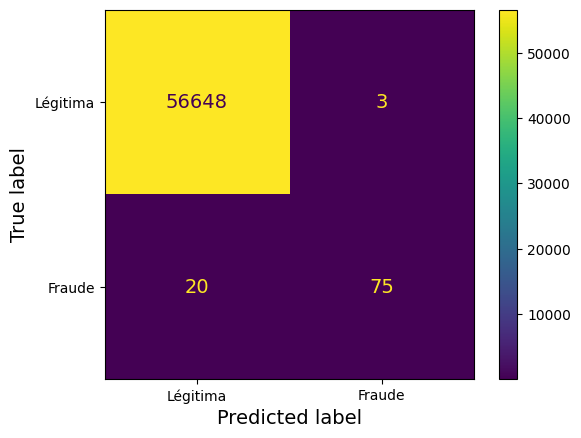

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Légitima", "Fraude"])
plt.show()

Agora calculamos as cinco métricas principais: acurácia, precisão, revocação (recall), F1-score e média de precisão.

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score

print("Acurácia: ", accuracy_score(y_test, y_pred))
print("Precisão: ", precision_score(y_test, y_pred))
print("Revocação: ", recall_score(y_test, y_pred))
print("F1-score: ", f1_score(y_test, y_pred))

# Precisa de probabilidades para calcular a média de precisão, diferente das outras métricas
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1] 
print("Média de Precisão: ", average_precision_score(y_test, y_proba_test)) 

Acurácia:  0.9995946850879357
Precisão:  0.9615384615384616
Revocação:  0.7894736842105263
F1-score:  0.8670520231213873
Média de Precisão:  0.8653518710549152


- Qual modelo teve melhor resultado e por que a sua escolha?

O melhor modelo foi o RandomForestClassifier com os hiperparametros otimizados, uma vez que em comparação com os outros dois modelos, também otimizados, este modelo superou com um avarege precision maior.
 

- Quais erros foram observados?

Utilizando como base a matriz de confusão, observamos que os seus resultados foram:

TP (Fraude classificada corretamente): 75

TN (Légitima classificada corretamente): 56.648

FP (Légitima classificada como fraude): 3

FN (Fraude classificada como légitima): 20

Isso indica que o modelo tem uma alta capacidade de acertar quando a transação é legitima ou fraudulenta, porém também erra uma parcela significativa ao associar fraudes à transações reais (Indicando a sua recall aproximada de 0.79).

- Quais limitações existem?

As principais limitações que foram notadas durante a realização desse trabalho foram:

1. O dataset é extremamente desbalanceado, sendo necessário fazer ajustes tanto no modelo quanto em seus parâmetros em concordância a esse problema.

2. O dataset possui variáveis que são previamente anonimizados (V1 a V28) pelo autor do banco de dados. Isso dificultou a criação de novas características originárias de alguma relação entre as variáveis.

- O que poderia ser melhorado?

Uma das principais coisas que poderiam ser melhorado seria a utilização de um algoritmo para a escolha de um limiar otimizado para que a métrica de revocação seja aprimorado, permitindo que mais transações fraudulentas fossem reconhecidas pelo modelo. Além disso, um GridSearch mais extenso para os modelos utilizados, com adição da busca exaustiva hiperparametros min_samples_split, min_samples_leaf para grid feito do RandomForestClassifier;